<div style="background:linear-gradient(135deg,#14b8a6 0%,#6366f1 100%);color:#ffffff;padding:26px 30px;border-radius:16px;font-family:'Segoe UI',Arial,sans-serif;">
  <div style="letter-spacing:.18em;font-size:12px;text-transform:uppercase;opacity:.85;">DS Elective 4 &nbsp;•&nbsp; Deep Learning</div>
  <div style="font-size:30px;font-weight:700;margin:6px 0 2px;">Laboratory Task 3</div>
  <div style="font-size:18px;opacity:.95;">Forward and Backward Propagation</div>
  <div style="font-size:13px;opacity:.8;margin-top:10px;">One full training step (forward pass, backpropagation, weight update) in NumPy</div>
</div>

**Name:** Edrian C. Jugan

# Task 3:Forward amd Backward Propagation

## 📌 Problem Statement

> **Instruction:** Perform a forward and backward propagation in python using the inputs from Laboratory Task 2.

```python
x = np.array([1, 0, 1])
y = np.array([1])

# use relu as the activation function.

# learning rate
lr = 0.001
```

We reuse the same network as Task 2 (3 inputs → 2 hidden units → 1 output) with **ReLU** as the activation and learning rate $\alpha = 0.001$.

## 🧠 The Math

We use the loss $E = \tfrac{1}{2}(\hat{y}-y)^2$, so $\dfrac{\partial E}{\partial \hat{y}} = \hat{y}-y$. The ReLU derivative is $f'(Z)=1$ if $Z>0$, else $0$.

| Step | Formula |
|---|---|
| **Forward** | $Z_h = xW_h + b_h,\quad A_h=f(Z_h),\quad Z_o = A_hW_o + \theta_3,\quad \hat{y}=f(Z_o)$ |
| **Output error** | $\delta_o = (\hat{y}-y)\cdot f'(Z_o)$ |
| **Hidden error** | $\delta_h = (\delta_o W_o^{T})\odot f'(Z_h)$ |
| **Gradients** | $\dfrac{\partial E}{\partial W_o}=A_h^{T}\delta_o,\quad \dfrac{\partial E}{\partial W_h}=x^{T}\delta_h,\quad \dfrac{\partial E}{\partial \theta}=\delta$ |
| **Update** | $W \leftarrow W - \alpha\,\dfrac{\partial E}{\partial W}$ |

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "font.size": 11,
})
TEAL, INDIGO, RED, ORANGE, GREY = "#14b8a6", "#6366f1", "#ef4444", "#f97316", "#94a3b8"

## 🔧 Setup

In [9]:
x = np.array([1, 0, 1])
y = np.array([1])

# use relu as the activation function.
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# learning rate
lr = 0.001

# parameters from Laboratory Task 2
W_h = np.array([[ 0.2, -0.3],
                [ 0.4,  0.1],
                [-0.5,  0.2]])       # (3 inputs x 2 hidden units)
W_o = np.array([[-0.3],
                [-0.2]])             # (2 hidden units x 1 output)
theta = np.array([-0.4, 0.2, 0.1])   # theta1, theta2 (hidden) | theta3 (output)

## ➡️ Forward Propagation

Same computation as Task 2, but we keep every $Z$ and activation because the backward pass needs them.

In [10]:
def forward(x, W_h, W_o, theta):
    Z_h = x @ W_h + theta[:2]        # weighted sums, hidden layer
    A_h = relu(Z_h)                  # hidden activations (H1, H2)
    Z_o = A_h @ W_o + theta[2]       # weighted sum, output layer (Z3)
    y_hat = relu(Z_o)                # prediction
    return Z_h, A_h, Z_o, y_hat

Z_h, A_h, Z_o, y_hat = forward(x, W_h, W_o, theta)
loss = 0.5 * np.sum((y_hat - y) ** 2)

print("Z_h    =", np.round(Z_h, 4))
print("A_h    =", np.round(A_h, 4))
print("Z_o    =", np.round(Z_o, 4))
print("y_hat  =", np.round(y_hat, 4))
print("loss   =", round(loss, 4))

Z_h    = [-0.7  0.1]
A_h    = [0.  0.1]
Z_o    = [0.08]
y_hat  = [0.08]
loss   = 0.4232


## ⬅️ Backward Propagation

**Hand calculation**

1. Output error: $\delta_o = (0.08-1)\cdot f'(0.08) = -0.92 \cdot 1 = \mathbf{-0.92}$
2. Hidden error: $\delta_h = [\,-0.92(-0.3),\; -0.92(-0.2)\,]\odot[\,f'(-0.7),\, f'(0.1)\,] = [\,0.276,\; 0.184\,]\odot[\,0,\,1\,] = \mathbf{[0,\; 0.184]}$
3. Gradients:
   - $\partial E/\partial W_o = A_h^T\delta_o = [0,\;0.1]^T(-0.92) = [\,0,\;-0.092\,]^T$
   - $\partial E/\partial W_h = x^T\delta_h$, which is $0.184$ for $w_{12}$ and $w_{16}$ and $0$ for everything else (because $x_2=0$ and $H_1$ was dead)
   - $\partial E/\partial\theta = [\,0,\;0.184,\;-0.92\,]$

Now the same thing in code:

In [11]:
# 1. output layer error
delta_o = (y_hat - y) * relu_derivative(Z_o)            # shape (1,)

# 2. hidden layer error
delta_h = (delta_o @ W_o.T) * relu_derivative(Z_h)      # shape (2,)

# 3. gradients
dW_o   = np.outer(A_h, delta_o) + 0.0                   # (2 x 1)  (+0.0 avoids printing -0.)
dW_h   = np.outer(x, delta_h)                           # (3 x 2)
dtheta = np.concatenate([delta_h, delta_o])             # theta1, theta2, theta3

print("delta_o  =", np.round(delta_o, 4))
print("delta_h  =", np.round(delta_h, 4))
print("\ndE/dW_o =\n", np.round(dW_o, 4))
print("\ndE/dW_h =\n", np.round(dW_h, 4))
print("\ndE/dtheta =", np.round(dtheta, 4))

delta_o  = [-0.92]
delta_h  = [0.    0.184]

dE/dW_o =
 [[ 0.   ]
 [-0.092]]

dE/dW_h =
 [[0.    0.184]
 [0.    0.   ]
 [0.    0.184]]

dE/dtheta = [ 0.     0.184 -0.92 ]


> 💡 $H_1$ was $0$ (its $Z_1$ was negative), so the whole first hidden unit gets a gradient of $0$: $w_{11}, w_{13}, w_{15}, \theta_1$ and $w_{21}$ do not change in this step.

## 🔄 Update the parameters

$W_{new} = W - \alpha \cdot \partial E/\partial W$ with $\alpha = 0.001$.

In [12]:
W_o_new   = W_o   - lr * dW_o
W_h_new   = W_h   - lr * dW_h
theta_new = theta - lr * dtheta

print("Updated hidden weights (w11 w12 / w13 w14 / w15 w16):\n", np.round(W_h_new, 6))
print("\nUpdated output weights (w21 / w22):\n", np.round(W_o_new, 6))
print("\nUpdated biases (theta1, theta2, theta3):", np.round(theta_new, 6))

Updated hidden weights (w11 w12 / w13 w14 / w15 w16):
 [[ 0.2      -0.300184]
 [ 0.4       0.1     ]
 [-0.5       0.199816]]

Updated output weights (w21 / w22):
 [[-0.3     ]
 [-0.199908]]

Updated biases (theta1, theta2, theta3): [-0.4       0.199816  0.10092 ]


## 📈 Did the update help?
Run the forward pass again with the new parameters. The loss should go down.

In [13]:
_, A_h_new, Z_o_new, y_hat_new = forward(x, W_h_new, W_o_new, theta_new)
loss_new = 0.5 * np.sum((y_hat_new - y) ** 2)

print(f"Before update -> y_hat = {y_hat[0]:.6f} | error = {(y_hat - y)[0]:.6f} | loss = {loss:.6f}")
print(f"After  update -> y_hat = {y_hat_new[0]:.6f} | error = {(y_hat_new - y)[0]:.6f} | loss = {loss_new:.6f}")

Before update -> y_hat = 0.080000 | error = -0.920000 | loss = 0.423200
After  update -> y_hat = 0.081040 | error = -0.918960 | loss = 0.422244


## 🎨 Gradients and loss at a glance

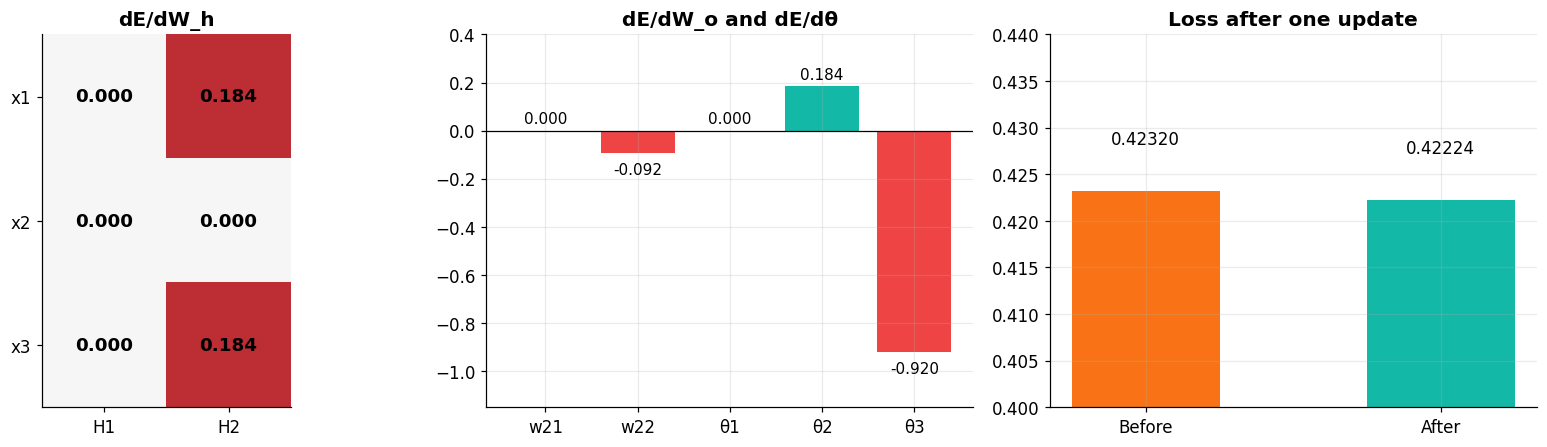

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) heatmap of dE/dW_h
im = axes[0].imshow(dW_h, cmap="RdBu_r", vmin=-0.25, vmax=0.25)
axes[0].grid(False)
for i in range(3):
    for j in range(2):
        axes[0].text(j, i, f"{dW_h[i, j]:.3f}", ha="center", va="center", fontsize=12, fontweight="bold")
axes[0].set_xticks([0, 1], ["H1", "H2"]); axes[0].set_yticks([0, 1, 2], ["x1", "x2", "x3"])
axes[0].set_title("dE/dW_h")

# (2) other gradients
labels = ["w21", "w22", "θ1", "θ2", "θ3"]
vals = [dW_o[0, 0], dW_o[1, 0], *dtheta]
axes[1].bar(labels, vals, color=[TEAL if v >= 0 else RED for v in vals])
axes[1].axhline(0, color="black", lw=.8)
for i, v in enumerate(vals):
    axes[1].text(i, v + (0.03 if v >= 0 else -0.09), f"{v:.3f}", ha="center", fontsize=10)
axes[1].set_ylim(-1.15, 0.4)
axes[1].set_title("dE/dW_o and dE/dθ")

# (3) loss before and after
axes[2].bar(["Before", "After"], [loss, loss_new], color=[ORANGE, TEAL], width=.5)
for i, v in enumerate([loss, loss_new]):
    axes[2].text(i, v + 0.005, f"{v:.5f}", ha="center", fontsize=11)
axes[2].set_ylim(0.40, 0.44)
axes[2].set_title("Loss after one update")

plt.tight_layout()
plt.show()

## 🔍 Check: numerical gradient

To prove the backprop formulas are right, we nudge each parameter by a tiny amount and measure how the loss changes (central difference). It should match our gradients.

In [15]:
def loss_fn():
    _, _, _, yh = forward(x, W_h, W_o, theta)
    return 0.5 * np.sum((yh - y) ** 2)

def numerical_grad(param, eps=1e-6):
    grad = np.zeros_like(param)
    for idx in np.ndindex(*param.shape):
        old = param[idx]
        param[idx] = old + eps; plus = loss_fn()
        param[idx] = old - eps; minus = loss_fn()
        param[idx] = old
        grad[idx] = (plus - minus) / (2 * eps)
    return grad

print("dW_h matches numerical gradient:   ", np.allclose(dW_h,   numerical_grad(W_h),   atol=1e-6))
print("dW_o matches numerical gradient:   ", np.allclose(dW_o,   numerical_grad(W_o),   atol=1e-6))
print("dtheta matches numerical gradient: ", np.allclose(dtheta, numerical_grad(theta), atol=1e-6))

dW_h matches numerical gradient:    True
dW_o matches numerical gradient:    True
dtheta matches numerical gradient:  True


## 🚀 Bonus: what if we keep repeating the step?
One step barely moves the loss because $\alpha = 0.001$ is small. Here we repeat the same forward and backward step many times to see the loss go down.

Loss at step 1    : 0.423200
Loss at step 5000 : 0.000018
Prediction after 5000 steps: 0.9940 (target = 1)


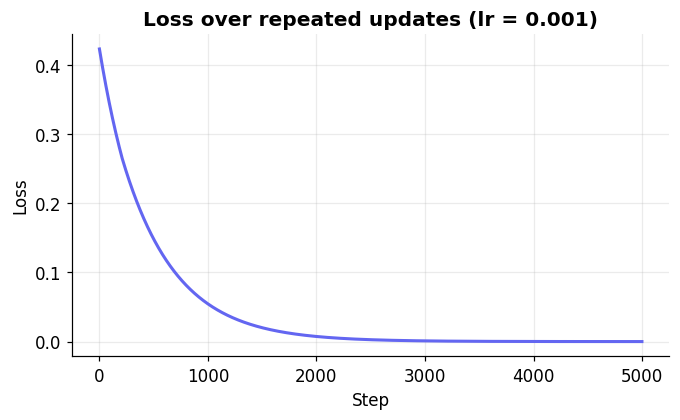

In [16]:
def train(steps, lr):
    Wh, Wo, th = W_h.copy(), W_o.copy(), theta.copy()
    history = []
    for _ in range(steps):
        Zh, Ah, Zo, yh = forward(x, Wh, Wo, th)
        history.append(0.5 * np.sum((yh - y) ** 2))
        d_o = (yh - y) * relu_derivative(Zo)
        d_h = (d_o @ Wo.T) * relu_derivative(Zh)
        Wo -= lr * np.outer(Ah, d_o)
        Wh -= lr * np.outer(x, d_h)
        th -= lr * np.concatenate([d_h, d_o])
    return history, yh

history, y_final = train(5000, lr)
print(f"Loss at step 1    : {history[0]:.6f}")
print(f"Loss at step 5000 : {history[-1]:.6f}")
print(f"Prediction after 5000 steps: {y_final[0]:.4f} (target = 1)")

plt.figure(figsize=(7, 3.8))
plt.plot(history, color=INDIGO, lw=2)
plt.xlabel("Step"); plt.ylabel("Loss"); plt.title("Loss over repeated updates (lr = 0.001)")
plt.show()

## ✅ Final Answer

**Forward pass:** $Z_h=[-0.7,\;0.1]$, $A_h=[0,\;0.1]$, $Z_3=0.08$, $\hat{y}=\mathbf{0.08}$, error $=\mathbf{-0.92}$

**Backward pass**

| Quantity | Value |
|---|---|
| $\delta_o$ | $-0.92$ |
| $\delta_h$ | $[\,0,\;0.184\,]$ |
| $\partial E/\partial w_{21},\,\partial E/\partial w_{22}$ | $0,\;-0.092$ |
| $\partial E/\partial w_{12},\,\partial E/\partial w_{16}$ | $0.184,\;0.184$ |
| $\partial E/\partial w_{11},\,w_{13},\,w_{14},\,w_{15}$ | $0$ |
| $\partial E/\partial \theta_1,\,\theta_2,\,\theta_3$ | $0,\;0.184,\;-0.92$ |

**Updated parameters** ($\alpha = 0.001$)

| Parameter | Old | New |
|---|---|---|
| $w_{12}$ | $-0.3$ | $-0.300184$ |
| $w_{16}$ | $0.2$ | $0.199816$ |
| $w_{22}$ | $-0.2$ | $-0.199908$ |
| $\theta_2$ | $0.2$ | $0.199816$ |
| $\theta_3$ | $0.1$ | $0.10092$ |
| all other weights and $\theta_1$ | unchanged | unchanged |

After the update, $\hat{y}$ moves from $0.08$ to about $0.0810$ and the loss drops from $0.4232$ to about $0.4222$.